In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.pipeline import make_pipeline
from sklearn.compose import make_column_selector, make_column_transformer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [39]:
class SocialNetworkDL:
    def __init__(self, file_path, target_column, test_size=0.3, random_state=42):
        self.file_path = file_path
        self.target_column = target_column
        self.test_size = test_size
        self.random_state = random_state
        self.df = None
        self.preprocessor = None
        self.model = None

    def load_data(self):


        print("Loading data...")
        self.df = pd.read_csv(self.file_path)
        print(f"Dataset loaded successfully...")


    def preprocess_data(self):

        self.load_data()

        print("Preprocessing data...")
        print("\n shape:",self.df.shape)
        print("\nStatistical Summary:",self.df.describe())
        print("Dataset Information:\n",self.df.info())
        print("Missing values:\n",self.df.isnull().sum())


        c = self.df.duplicated().sum()
        print("Duplicate values:",c)

        if c > 0:
          self.df = self.df.drop_duplicates()
          print(f"Removed {c} duplicate rows.")

        print("After removing duplicate rows shape of dataset:",self.df.shape)


    def prepare_data(self):

        self.preprocess_data()

        X = self.df.drop(self.target_column, axis=1)
        y = self.df[self.target_column].values

        self.X_train, self.X_test, self.y_train, self.y_test = train_test_split(
            X, y, test_size=self.test_size, random_state=self.random_state
        )

        # Build Preprocessing Pipeline
        self.preprocessor = make_column_transformer(
            (OneHotEncoder(handle_unknown='ignore'), make_column_selector(dtype_include=object)),
            (StandardScaler(), make_column_selector(dtype_include=np.number)),
            remainder="passthrough"
        )

        # Fit and Transform the data through the pipeline
        self.X_train = self.preprocessor.fit_transform(self.X_train)
        self.X_test = self.preprocessor.transform(self.X_test)
        print("Data preprocessed through Pipeline successfully.")

    def build_dl_model(self):

        self.prepare_data()

        print("Building Deep Learning Model...")
        input_dim = self.X_train.shape[1]

        self.model = tf.keras.models.Sequential([
            tf.keras.layers.Dense(12, activation='relu', input_shape=(input_dim,)),
            tf.keras.layers.Dense(8, activation='relu'),
            tf.keras.layers.Dense(1, activation='sigmoid')
        ])

        self.model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

    def train_model(self):

        self.build_dl_model()

        print("Training Neural Network...")
        self.model.fit(self.X_train, self.y_train, epochs=100, batch_size=10, verbose=0)
        print("Model Training Completed.")

    def evaluate_model(self):

        self.train_model()

        print("Evaluating model performance...")


        y_pred_prob = self.model.predict(self.X_test, verbose=0)
        y_pred = (y_pred_prob > 0.5).astype(int)

        acc = accuracy_score(self.y_test, y_pred)
        print(f"\nTest Accuracy: {acc*100:.2f}%")

        # Visualizing Confusion Matrix
        cm = confusion_matrix(self.y_test, y_pred)
        plt.figure(figsize=(6, 4))
        sns.heatmap(cm, annot=True, fmt="g", cmap="YlGnBu")
        plt.title("Deep Learning Confusion Matrix")
        plt.xlabel("Predicted")
        plt.ylabel("Actual")
        plt.show()

Loading data...
Dataset loaded successfully...
Preprocessing data...

 shape: (400, 3)

Statistical Summary:               Age  EstimatedSalary   Purchased
count  400.000000       400.000000  400.000000
mean    37.655000     69742.500000    0.357500
std     10.482877     34096.960282    0.479864
min     18.000000     15000.000000    0.000000
25%     29.750000     43000.000000    0.000000
50%     37.000000     70000.000000    0.000000
75%     46.000000     88000.000000    1.000000
max     60.000000    150000.000000    1.000000
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Age              400 non-null    int64
 1   EstimatedSalary  400 non-null    int64
 2   Purchased        400 non-null    int64
dtypes: int64(3)
memory usage: 9.5 KB
Dataset Information:
 None
Missing values:
 Age                0
EstimatedSalary    0
Purchased          0

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model Training Completed.
Evaluating model performance...

Test Accuracy: 90.99%


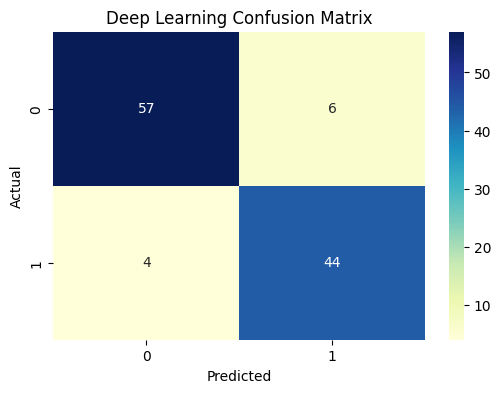

In [40]:
if __name__ == "__main__":
    DATA_PATH = "Social_Network_Ads.csv"

    # Run the entire workflow
    model = SocialNetworkDL(DATA_PATH, "Purchased")
    model.evaluate_model()